In [33]:
import pandas as pd
import numpy as np
from tqdm import tqdm

In [34]:
# ============================================================
# 1. CHARGEMENT
# ============================================================
df = pd.read_csv('../data_train_databattle2026/segment_alerts_all_airports_train.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['airport_alert_id', 'date']).reset_index(drop=True)


In [35]:
# ============================================================
# 2. FONCTION PRINCIPALE : CRÉATION DES SNAPSHOTS
# ============================================================
# Logique : pour chaque éclair i dans une alerte,
# on crée des snapshots à t+1, t+5, t+10, t+15, t+20, t+25, t+29 min
# APRÈS cet éclair, en simulant ce que l'opérateur verrait à cet instant.

SNAPSHOT_OFFSETS = [1, 5, 10, 15, 20, 25, 29]  # minutes après le dernier éclair
HORIZON = 30          # minutes : fenêtre de danger
DIST_DANGER = 20      # km : rayon de danger autour de l'aéroport
WINDOW_RECENT = 15    # minutes : fenêtre glissante pour les features récentes

def compute_centroid_velocity(recent_eclairs):
    """
    Calcule la vitesse et direction de déplacement du centroïde
    des éclairs récents. Retourne (vitesse_km_min, direction_degres).
    """
    if len(recent_eclairs) < 2:
        return 0.0, 0.0

    # On coupe en deux moitiés temporelles
    mid = len(recent_eclairs) // 2
    first_half = recent_eclairs.iloc[:mid]
    second_half = recent_eclairs.iloc[mid:]

    lat1 = first_half['lat'].mean()
    lon1 = first_half['lon'].mean()
    lat2 = second_half['lat'].mean()
    lon2 = second_half['lon'].mean()

    dt_minutes = (
        second_half['date'].mean() - first_half['date'].mean()
    ).total_seconds() / 60.0

    if dt_minutes <= 0:
        return 0.0, 0.0

    # Distance approx en km (hypothèse plan local, suffisant à 30km)
    dlat_km = (lat2 - lat1) * 111.0
    dlon_km = (lon2 - lon1) * 111.0 * np.cos(np.radians((lat1 + lat2) / 2))
    dist_km = np.sqrt(dlat_km**2 + dlon_km**2)
    vitesse = dist_km / dt_minutes

    # Direction en degrés (0=Nord, 90=Est)
    direction = np.degrees(np.arctan2(dlon_km, dlat_km)) % 360

    return vitesse, direction


def build_snapshots(df):
    snapshots = []

    # On travaille uniquement sur les éclairs appartenant à une alerte
    df_alertes = df.dropna(subset=['airport_alert_id']).copy()
    df_alertes['airport_alert_id'] = df_alertes['airport_alert_id'].astype(int)
    
    alerts = df_alertes['airport_alert_id'].unique()
    print(f"Construction des snapshots pour {len(alerts)} alertes...")

    for alert_id in tqdm(alerts):
        alert = df_alertes[df_alertes['airport_alert_id'] == alert_id].copy()
        alert = alert.sort_values('date').reset_index(drop=True)
        
        # Nom de l'aéroport (constant dans une alerte)
        airport_name = alert['airport'].iloc[0]
        
        # IMPORTANT : pour calculer la target, on prend TOUS les éclairs
        # de cet aéroport (y compris hors-alerte) après T_snap
        tous_eclairs_airport = df[df['airport'] == airport_name].copy()

        n = len(alert)

        for i in range(n):
            eclair_i = alert.iloc[i]
            T_last = eclair_i['date']
            historique = alert.iloc[:i+1]

            T_window_start = T_last - pd.Timedelta(minutes=WINDOW_RECENT)
            recent = historique[historique['date'] >= T_window_start]

            # Taux d'éclairs
            alert['minute_bin'] = (
                (alert['date'] - alert['date'].min()).dt.total_seconds() // 300
            )
            rates = alert[alert['date'] <= T_last].groupby('minute_bin').size()
            peak_rate = rates.max() if len(rates) > 0 else 0
            current_rate = rates.iloc[-1] if len(rates) > 0 else 0

            centroid_vel, centroid_dir = compute_centroid_velocity(recent)

            if len(recent) >= 3:
                x = np.arange(len(recent))
                trend_dist = np.polyfit(x, recent['dist'].values, 1)[0]
                trend_amp  = np.polyfit(x, recent['amplitude'].abs().values, 1)[0]
            else:
                trend_dist = 0.0
                trend_amp  = 0.0

            for k in SNAPSHOT_OFFSETS:
                T_snap = T_last + pd.Timedelta(minutes=k)

                # Un éclair est tombé dans l'alerte avant k min → gap terminé
                eclairs_entre = alert[
                    (alert['date'] > T_last) &
                    (alert['date'] <= T_snap)
                ]
                if len(eclairs_entre) > 0:
                    break

                # TARGET : éclair nuage-sol dangereux dans les (30-k) min suivantes
                # Sur TOUS les éclairs de l'aéroport, pas seulement ceux de l'alerte
                T_danger_end = T_snap + pd.Timedelta(minutes=(HORIZON - k))
                eclairs_dangereux = tous_eclairs_airport[
                    (tous_eclairs_airport['date'] > T_snap) &
                    (tous_eclairs_airport['date'] <= T_danger_end) &
                    (tous_eclairs_airport['icloud'] == False) &
                    (tous_eclairs_airport['dist'] <= DIST_DANGER)
                ]
                target = 1 if len(eclairs_dangereux) > 0 else 0

                snap = {
                    'airport_alert_id':          alert_id,
                    'T_snap':                    T_snap,
                    'T_last_eclair':             T_last,
                    'T_reprise_reglementaire':   T_last + pd.Timedelta(minutes=HORIZON),

                    # GROUPE A
                    'silence_duration':          k,
                    'last_dist':                 eclair_i['dist'],
                    'last_amplitude':            eclair_i['amplitude'],
                    'last_icloud':               int(eclair_i['icloud']),
                    'last_azimuth':              eclair_i['azimuth'],

                    # GROUPE B
                    'n_eclairs_15min':           len(recent),
                    'n_sol_15min':               int((recent['icloud'] == False).sum()),
                    'mean_dist_15min':           recent['dist'].mean(),
                    'max_dist_15min':            recent['dist'].max(),
                    'min_dist_15min':            recent['dist'].min(),
                    'trend_dist_15min':          trend_dist,
                    'mean_amp_15min':            recent['amplitude'].abs().mean(),
                    'trend_amp_15min':           trend_amp,
                    'ratio_ic_15min':            recent['icloud'].mean(),
                    'centroid_velocity':         centroid_vel,
                    'centroid_direction':        centroid_dir,

                    # GROUPE C
                    'alert_duration_so_far':     (T_last - alert['date'].min())
                                                 .total_seconds() / 60.0,
                    'total_eclairs_so_far':      len(historique),
                    'total_sol_so_far':          int((historique['icloud'] == False).sum()),
                    'peak_rate_5min':            peak_rate,
                    'current_vs_peak_rate':      current_rate / max(peak_rate, 1),

                    # GROUPE D — colonne 'airport' directement
                    'airport_id':               airport_name,
                    'month':                    T_snap.month,
                    'hour_utc':                 T_snap.hour,

                    'target': target
                }
                snapshots.append(snap)

    df_snap = pd.DataFrame(snapshots)
    print(f"Dataset snapshots : {len(df_snap)} lignes")
    print(f"Taux de danger (target=1) : {df_snap['target'].mean():.3f}")
    return df_snap

In [36]:
# ============================================================
# 3. SÉPARATION TRAIN / TEST SANS FUITE TEMPORELLE
# ============================================================
def split_train_test(df_snap, split_date='2024-01-01'):
    # Ajouter utc=True pour matcher le timezone des données
    split_dt = pd.Timestamp(split_date, tz='UTC')

    alert_start = df_snap.groupby('airport_alert_id')['T_last_eclair'].min()

    train_alerts = alert_start[alert_start < split_dt].index
    test_alerts  = alert_start[alert_start >= split_dt].index

    df_train = df_snap[df_snap['airport_alert_id'].isin(train_alerts)].copy()
    df_test  = df_snap[df_snap['airport_alert_id'].isin(test_alerts)].copy()

    print(f"Train : {len(df_train)} snapshots ({len(train_alerts)} alertes)")
    print(f"Test  : {len(df_test)} snapshots ({len(test_alerts)} alertes)")
    print(f"Taux danger train : {df_train['target'].mean():.3f}")
    print(f"Taux danger test  : {df_test['target'].mean():.3f}")

    return df_train, df_test

In [37]:
# ============================================================
# 4. EXÉCUTION
# ============================================================
df_snap = build_snapshots(df)
df_snap['airport_id'] = df_snap['airport_id'].astype('category')

Construction des snapshots pour 769 alertes...


100%|██████████| 769/769 [04:22<00:00,  2.93it/s]


Dataset snapshots : 42386 lignes
Taux de danger (target=1) : 0.226


In [38]:
alert_dates = df_snap.groupby('airport_alert_id')['T_last_eclair'].min().sort_values()
split_date_auto = alert_dates.iloc[int(len(alert_dates) * 0.8)]
print(f"Date de split automatique (80%) : {split_date_auto}")

df_train, df_test = split_train_test(df_snap, split_date=split_date_auto.strftime('%Y-%m-%d'))

# Colonnes features (exclure les identifiants et la target)
META_COLS = ['airport_alert_id', 'T_snap', 'T_last_eclair',
             'T_reprise_reglementaire', 'target']
FEATURE_COLS = [c for c in df_snap.columns if c not in META_COLS]

X_train = df_train[FEATURE_COLS]
y_train = df_train['target']
X_test  = df_test[FEATURE_COLS]
y_test  = df_test['target']

print(f"\nFeatures : {FEATURE_COLS}")

Date de split automatique (80%) : 2020-12-06 22:12:07+00:00
Train : 39311 snapshots (612 alertes)
Test  : 3075 snapshots (157 alertes)
Taux danger train : 0.194
Taux danger test  : 0.633

Features : ['silence_duration', 'last_dist', 'last_amplitude', 'last_icloud', 'last_azimuth', 'n_eclairs_15min', 'n_sol_15min', 'mean_dist_15min', 'max_dist_15min', 'min_dist_15min', 'trend_dist_15min', 'mean_amp_15min', 'trend_amp_15min', 'ratio_ic_15min', 'centroid_velocity', 'centroid_direction', 'alert_duration_so_far', 'total_eclairs_so_far', 'total_sol_so_far', 'peak_rate_5min', 'current_vs_peak_rate', 'airport_id', 'month', 'hour_utc']


In [39]:
import lightgbm as lgb
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GroupKFold
from sklearn.metrics import brier_score_loss, roc_auc_score
from codecarbon import EmissionsTracker
import joblib
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. GESTION DU DÉSÉQUILIBRE
# ============================================================
groups_array = df_train['airport_alert_id'].values
gkf = GroupKFold(n_splits=5)
folds = list(gkf.split(X_train, y_train, groups=groups_array))

# Dernier fold = données les plus récentes → fold de calibration
cal_train_idx, cal_val_idx = folds[-1]

X_cal_train = X_train.iloc[cal_train_idx]
y_cal_train = y_train.iloc[cal_train_idx]
X_cal_val   = X_train.iloc[cal_val_idx]
y_cal_val   = y_train.iloc[cal_val_idx]

ratio_desequilibre = (y_cal_train == 0).sum() / (y_cal_train == 1).sum()
print(f"Ratio déséquilibre (fold entraînement) : {ratio_desequilibre:.1f}")
print(f"  {(y_cal_train==0).sum()} sûrs / {(y_cal_train==1).sum()} dangereux")
print(f"Taille fold calibration : {len(y_cal_val)} snapshots")

# ============================================================
# 2. ENTRAÎNEMENT SUR 80% DU TRAIN (fold cal_train)
# ============================================================
base_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    num_leaves=40,
    min_child_samples=50,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio_desequilibre,
    n_jobs=2,
    device='cpu',
    random_state=42,
    verbose=-1
)

print("\nEntraînement du modèle de base...")
# tracker = EmissionsTracker(
#     project_name="databattle_meteorage",
#     output_dir="./carbon_tracking",
#     log_level="error"   # silencieux sauf erreur
# )
# tracker.start()
base_model.fit(X_cal_train, y_cal_train)
# emissions = tracker.stop()
# print(f"Emissions CO2 entraînement : {emissions * 1e6:.2f} µgCO2eq")

# ============================================================
# 3. CALIBRATION SUR LE FOLD DE VALIDATION (20% les plus récents)
# ============================================================
# cv='prefit' : le modèle est déjà entraîné,
# on utilise X_cal_val/y_cal_val uniquement pour calibrer les probas
model_calibrated = CalibratedClassifierCV(
    estimator=base_model,
    method='isotonic',
    cv='prefit'
)
print("Calibration des probabilités...")
model_calibrated.fit(X_cal_val, y_cal_val)

# ============================================================
# 4. VÉRIFICATION RAPIDE
# ============================================================
probs_check = model_calibrated.predict_proba(X_cal_val)[:, 1]
auc_check   = roc_auc_score(y_cal_val, probs_check)
brier_check = brier_score_loss(y_cal_val, probs_check)
print(f"\nVérification sur fold calibration :")
print(f"  AUC-ROC     : {auc_check:.4f}  (viser > 0.85)")
print(f"  Brier Score : {brier_check:.4f}  (viser < 0.10)")

# ============================================================
# 5. SAUVEGARDE
# ============================================================
joblib.dump(model_calibrated, './model_calibrated.pkl')
joblib.dump(FEATURE_COLS, './feature_cols.pkl')
print("\nModèle sauvegardé → model_calibrated.pkl")

Ratio déséquilibre (fold entraînement) : 4.1
  25336 sûrs / 6116 dangereux
Taille fold calibration : 7859 snapshots

Entraînement du modèle de base...
Calibration des probabilités...

Vérification sur fold calibration :
  AUC-ROC     : 0.8715  (viser > 0.85)
  Brier Score : 0.0906  (viser < 0.10)

Modèle sauvegardé → model_calibrated.pkl


AUC-ROC : 0.8621
Brier Score : 0.1439


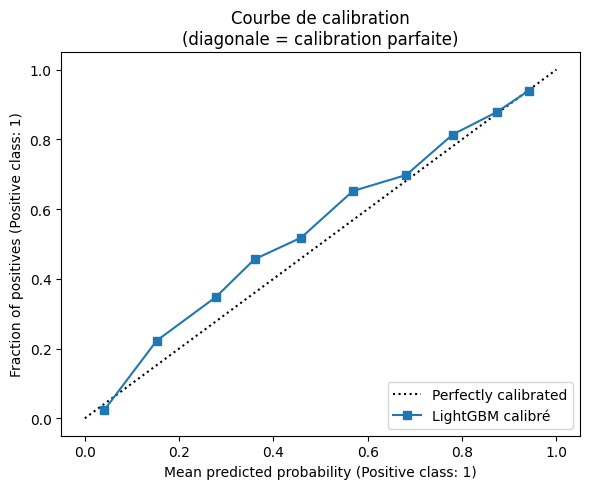


=== RÉSULTATS MÉTIER ===
 seuil  taux_fausse_levee  gain_moyen_minutes  n_fausses_levees  n_alertes_total  couverture
  0.70           0.273885           13.359649                43              157    1.000000
  0.75           0.237179           11.966387                37              157    0.993631
  0.80           0.237179           11.966387                37              157    0.993631
  0.85           0.141935            8.127820                22              157    0.987261
  0.90           0.021277            2.934783                 3              157    0.898089
  0.92           0.014286            2.833333                 2              157    0.891720
  0.94           0.017241            1.877193                 2              157    0.738854
  0.95           0.018692            1.628571                 2              157    0.681529
  0.96           0.018692            1.628571                 2              157    0.681529
  0.97           0.000000            1.53086

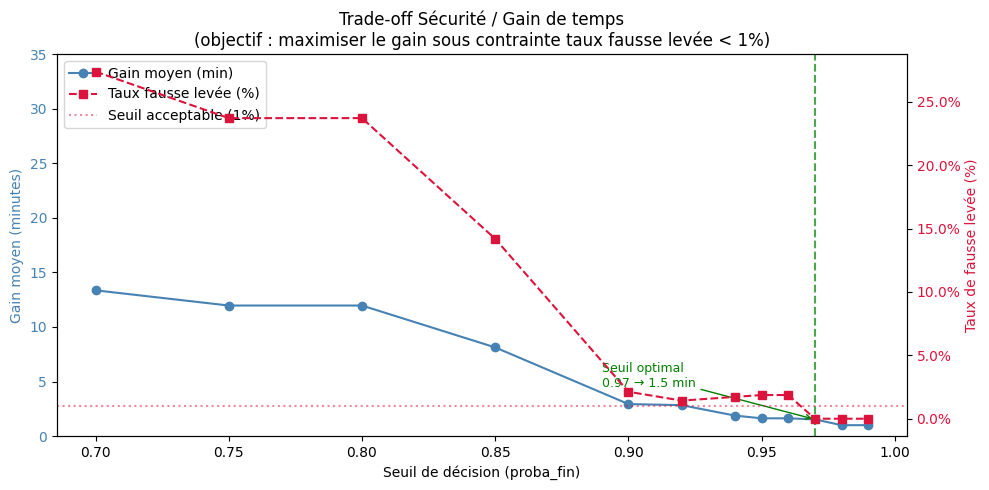


=== RAPPORT FINAL ===
AUC-ROC            : 0.8621
Brier Score        : 0.1439

Seuil de production recommandé : 0.97
  → Gain moyen garanti          : 1.5 min/alerte
  → Taux de fausse levée        : 0.00%
  → Couverture des alertes      : 51.6%


In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    brier_score_loss
)
from sklearn.calibration import CalibrationDisplay  # ← bon module
import joblib

model_calibrated = joblib.load('./model_calibrated.pkl')
FEATURE_COLS = joblib.load('./feature_cols.pkl')

probs_test = model_calibrated.predict_proba(X_test)[:, 1]
df_test_eval = df_test.copy()
df_test_eval['proba_danger'] = probs_test
# proba_danger ≈ P(un éclair sol dangereux dans les 30 min)
# On lève l'alerte quand proba_danger est FAIBLE
df_test_eval['proba_fin'] = 1 - probs_test

# ============================================================
# MÉTRIQUE 1 — AUC & Courbe ROC
# (Mesure la discrimination globale du modèle)
# ============================================================
auc = roc_auc_score(y_test, probs_test)
fpr, tpr, thresholds_roc = roc_curve(y_test, probs_test)

print(f"AUC-ROC : {auc:.4f}")
# Interprétation : 0.5 = aléatoire, 1.0 = parfait
# Pour ce problème, viser > 0.85

# ============================================================
# MÉTRIQUE 2 — Brier Score
# (Qualité de calibration des probabilités)
# ============================================================
brier = brier_score_loss(y_test, probs_test)
print(f"Brier Score : {brier:.4f}")
# Interprétation : 0 = parfait, 0.25 = modèle nul (prédire 0.5 partout)
# Viser < 0.05

# ============================================================
# MÉTRIQUE 3 — COURBE DE CALIBRATION
# (Est-ce que P=0.9 veut vraiment dire 90% de danger ?)
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))
CalibrationDisplay.from_predictions(
    y_test, probs_test,
    n_bins=10, ax=ax, name='LightGBM calibré'
)
ax.set_title('Courbe de calibration\n(diagonale = calibration parfaite)')
plt.tight_layout()
plt.savefig('./calibration_curve.png', dpi=150)
plt.show()

# ============================================================
# MÉTRIQUE 4 — ÉVALUATION MÉTIER (LA PLUS IMPORTANTE)
# ============================================================
# Pour chaque alerte et chaque seuil de décision, on simule
# ce que ferait un opérateur en temps réel.
# Il lève l'alerte au PREMIER snapshot où proba_fin >= seuil.

def evaluate_metier(df_eval, seuils):
    """
    Simule la décision opérationnelle pour chaque seuil.
    
    Retourne un DataFrame avec pour chaque seuil :
    - taux_fausse_levee : % d'alertes levées à tort (danger réel ensuite)
    - gain_moyen_minutes : gain de temps moyen sur les alertes sûres
    - couverture : % d'alertes où l'IA prend une décision (vs attendre 30 min)
    """
    results = []

    for seuil in seuils:
        fausses_levees = 0
        vrais_gains = []
        alertes_sans_decision = 0

        for alert_id, group in df_eval.groupby('airport_alert_id'):
            group = group.sort_values('T_snap')

            T_reglementaire = group['T_reprise_reglementaire'].max()

            # L'IA lève l'alerte au premier snapshot où proba_fin >= seuil
            # ET silence_duration >= 5 min (garde-fou minimal)
            candidats = group[
                (group['proba_fin'] >= seuil) &
                (group['silence_duration'] >= 5)
            ]

            if candidats.empty:
                # L'IA ne prend pas de décision → on attend les 30 min
                alertes_sans_decision += 1
                continue

            T_decision_ia = candidats['T_snap'].iloc[0]

            # Vérification sécurité : y a-t-il un éclair sol dangereux
            # APRÈS la décision IA ?
            # On regarde dans les données originales
            alert_raw = df[df['airport_alert_id'] == alert_id]
            eclairs_post = alert_raw[
                (alert_raw['date'] > T_decision_ia) &
                (alert_raw['icloud'] == False) &
                (alert_raw['dist'] <= DIST_DANGER)
            ]

            if len(eclairs_post) > 0:
                fausses_levees += 1
            else:
                gain = (T_reglementaire - T_decision_ia).total_seconds() / 60.0
                if gain > 0:
                    vrais_gains.append(gain)

        n_alertes = df_eval['airport_alert_id'].nunique()
        n_decisions = n_alertes - alertes_sans_decision

        results.append({
            'seuil':               seuil,
            'taux_fausse_levee':   fausses_levees / max(n_decisions, 1),
            'gain_moyen_minutes':  np.mean(vrais_gains) if vrais_gains else 0.0,
            'gain_median_minutes': np.median(vrais_gains) if vrais_gains else 0.0,
            'n_fausses_levees':    fausses_levees,
            'n_alertes_total':     n_alertes,
            'couverture':          n_decisions / n_alertes,
        })

    return pd.DataFrame(results)


SEUILS = [0.70, 0.75, 0.80, 0.85, 0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
df_results = evaluate_metier(df_test_eval, SEUILS)

print("\n=== RÉSULTATS MÉTIER ===")
print(df_results[[
    'seuil', 'taux_fausse_levee', 'gain_moyen_minutes',
    'n_fausses_levees', 'n_alertes_total', 'couverture'
]].to_string(index=False))

# ============================================================
# MÉTRIQUE 5 — COURBE SÉCURITÉ / GAIN (graphe clé pour le jury)
# ============================================================
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Seuil de décision (proba_fin)')
ax1.set_ylabel('Gain moyen (minutes)', color='steelblue')
ax1.plot(df_results['seuil'], df_results['gain_moyen_minutes'],
         'o-', color='steelblue', label='Gain moyen (min)')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, 35)

ax2 = ax1.twinx()
ax2.set_ylabel('Taux de fausse levée (%)', color='crimson')
ax2.plot(df_results['seuil'], df_results['taux_fausse_levee'] * 100,
         's--', color='crimson', label='Taux fausse levée (%)')
ax2.axhline(y=1.0, color='crimson', linestyle=':', alpha=0.5,
            label='Seuil acceptable (1%)')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

# Zone acceptable : taux fausse levée < 1%
seuil_securite = df_results[df_results['taux_fausse_levee'] <= 0.01]
if len(seuil_securite) > 0:
    best = seuil_securite.iloc[0]
    ax1.axvline(x=best['seuil'], color='green', linestyle='--', alpha=0.7)
    ax1.annotate(
        f"Seuil optimal\n{best['seuil']:.2f} → {best['gain_moyen_minutes']:.1f} min",
        xy=(best['seuil'], best['gain_moyen_minutes']),
        xytext=(best['seuil'] - 0.08, best['gain_moyen_minutes'] + 3),
        fontsize=9, color='green',
        arrowprops=dict(arrowstyle='->', color='green')
    )

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Trade-off Sécurité / Gain de temps\n(objectif : maximiser le gain sous contrainte taux fausse levée < 1%)')
plt.tight_layout()
plt.savefig('./tradeoff_securite_gain.png', dpi=150)
plt.show()

# ============================================================
# RAPPORT FINAL
# ============================================================
print("\n=== RAPPORT FINAL ===")
print(f"AUC-ROC            : {auc:.4f}")
print(f"Brier Score        : {brier:.4f}")

seuil_optimal = df_results[df_results['taux_fausse_levee'] <= 0.01]
if len(seuil_optimal) > 0:
    best = seuil_optimal.iloc[0]
    print(f"\nSeuil de production recommandé : {best['seuil']:.2f}")
    print(f"  → Gain moyen garanti          : {best['gain_moyen_minutes']:.1f} min/alerte")
    print(f"  → Taux de fausse levée        : {best['taux_fausse_levee']*100:.2f}%")
    print(f"  → Couverture des alertes      : {best['couverture']*100:.1f}%")
else:
    print("\nAucun seuil ne satisfait la contrainte de sécurité < 1%.")
    print("→ Le modèle doit être amélioré avant mise en production.")

In [42]:
print(f"Taille X_train : {X_train.shape}")
print(f"Taille X_test  : {X_test.shape}")
print(f"Taille df_test : {len(df_test)}")

# Vérifie la distribution temporelle de tes alertes
alert_dates = df_snap.groupby('airport_alert_id')['T_last_eclair'].min()
print(f"\nDate min des alertes : {alert_dates.min()}")
print(f"Date max des alertes : {alert_dates.max()}")
print(f"Nombre d'alertes avant 2023 : {(alert_dates < pd.Timestamp('2023-01-01', tz='UTC')).sum()}")
print(f"Nombre d'alertes après 2023 : {(alert_dates >= pd.Timestamp('2023-01-01', tz='UTC')).sum()}")

Taille X_train : (39311, 24)
Taille X_test  : (3075, 24)
Taille df_test : 3075

Date min des alertes : 2016-01-02 21:22:53+00:00
Date max des alertes : 2022-12-11 06:55:52+00:00
Nombre d'alertes avant 2023 : 769
Nombre d'alertes après 2023 : 0
